# __Patrón estructural - Decorator__

La tarifa del peaje no es un valor fijo. Hay una tarifa base según la categoría (I auto, II bus, III camión) y sobre eso se le aplican reglas que el concesionario cambia por resolución: recargo del 15% en hora pico, 10% de descuento con TAG, $5.000 por eje adicional, 50% si es residente del municipio.

El problema es que esas reglas se mezclan entre sí. Un camión de un residente, en hora pico, con TAG y dos ejes extra es un caso normal, y la factura debe mostrar el desglose y no solamente el total.

Por eso sirve Decorator: se va envolviendo un objeto en otros que comparten la misma interfaz y cada uno pone su parte, así las combinaciones salen solas sin tener que escribirlas una por una.

## Sin patrón

La versión con un booleano por regla. Funciona, el problema es mantenerla.

Cada regla nueva es un parámetro más y un if más, y el orden en que se aplican queda cableado en el orden de los if. Tampoco hay forma de sacar el desglose sin repetir toda la cuenta. Y las llamadas quedan ilegibles, `calcular_tarifa("III", True, True, 2, True)` no dice absolutamente nada.

La otra salida sería hacer subclases tipo `TarifaCamionPicoTagResidente`, pero eso son 2^n clases para n reglas, o sea peor.

In [1]:
# -------------------------------------------------------------------
# VERSION SIN PATRON: una funcion con una bandera por cada regla
# -------------------------------------------------------------------

def calcular_tarifa(categoria, hora_pico=False, tiene_tag=False, ejes_extra=0, es_residente=False):
    # tarifa base segun categoria
    if categoria == "I":
        total = 11000
    elif categoria == "II":
        total = 18500
    elif categoria == "III":
        total = 30000
    else:
        total = 0

    # ...y aqui empieza a crecer sin control
    if hora_pico:
        total = total * 1.15
    if tiene_tag:
        total = total * 0.90
    if ejes_extra > 0:
        total = total + ejes_extra * 5000
    if es_residente:
        total = total * 0.50

    return round(total)


print("Auto normal            :", calcular_tarifa("I"))
print("Auto en hora pico      :", calcular_tarifa("I", True))
print("Auto pico + TAG        :", calcular_tarifa("I", True, True))
print("Camion pico+TAG+2 ejes :", calcular_tarifa("III", True, True, 2))
print("Camion todo + residente:", calcular_tarifa("III", True, True, 2, True))
print()
print(">>> Y ahora... que significa calcular_tarifa('III', True, True, 2, True) ?")
print(">>> Ademas solo devuelve un numero: no puedo imprimir el desglose en la factura.")

Auto normal            : 11000
Auto en hora pico      : 12650
Auto pico + TAG        : 11385
Camion pico+TAG+2 ejes : 41050
Camion todo + residente: 20525

>>> Y ahora... que significa calcular_tarifa('III', True, True, 2, True) ?
>>> Ademas solo devuelve un numero: no puedo imprimir el desglose en la factura.


Llega la resolución del descuento nocturno del 20% y toca meterle mano a una función que ya estaba probada:

In [2]:
# Toca modificar la firma Y el cuerpo de la funcion que ya funcionaba
def calcular_tarifa_v2(categoria, hora_pico=False, tiene_tag=False, ejes_extra=0,
                       es_residente=False, es_nocturno=False):   # <-- parametro 6
    if categoria == "I":
        total = 11000
    elif categoria == "II":
        total = 18500
    elif categoria == "III":
        total = 30000
    else:
        total = 0

    if hora_pico:
        total = total * 1.15
    if tiene_tag:
        total = total * 0.90
    if ejes_extra > 0:
        total = total + ejes_extra * 5000
    if es_residente:
        total = total * 0.50
    if es_nocturno:          # <-- if numero 5
        total = total * 0.80

    return round(total)


print("Auto nocturno con TAG:", calcular_tarifa_v2("I", False, True, 0, False, True))
print()
print(">>> Modifique una funcion que YA funcionaba y estaba probada (violacion de Abierto/Cerrado).")
print(">>> Con 6 reglas booleanas hay 2^5 = 32 combinaciones posibles de comportamiento.")

Auto nocturno con TAG: 7920

>>> Modifique una funcion que YA funcionaba y estaba probada (violacion de Abierto/Cerrado).
>>> Con 6 reglas booleanas hay 2^5 = 32 combinaciones posibles de comportamiento.


## Aplicando el patrón decorator

`Cobro` es la interfaz, con `monto()` y `detalle()`. `TarifaBase` es lo único que existe de verdad, la tarifa pelada. `DecoradorCobro` es la envoltura: es un `Cobro` y al mismo tiempo guarda un `Cobro` adentro, y por eso las envolturas se pueden apilar unas sobre otras sin límite.

De ahí para abajo cada regla es una clase que solo sabe hacer su parte y le pide el resto al objeto que envuelve. `detalle()` es el que resuelve lo de la factura, cada decorador le agrega su línea al desglose que le llega de adentro.

In [3]:
# =========================================================
# ROL: COMPONENT -> interfaz comun de "algo que se cobra"
# =========================================================
class Cobro:
    def monto(self):
        raise NotImplementedError("Todo cobro debe saber cuanto vale")

    def detalle(self):
        raise NotImplementedError("Todo cobro debe saber explicar su desglose")


# =========================================================
# ROL: CONCRETE COMPONENT -> la tarifa pelada, sin reglas
# =========================================================
class TarifaBase(Cobro):
    PRECIOS = {"I": 11000, "II": 18500, "III": 30000}

    def __init__(self, categoria):
        self.categoria = categoria

    def monto(self):
        return self.PRECIOS[self.categoria]

    def detalle(self):
        return [f"Tarifa base categoria {self.categoria} .......... ${self.monto()}"]


# =========================================================
# ROL: DECORATOR -> ES un Cobro y TIENE un Cobro
# Por defecto delega todo; las subclases modifican lo que necesiten.
# =========================================================
class DecoradorCobro(Cobro):
    def __init__(self, cobro):
        self.cobro = cobro     # el objeto envuelto (puede ser otro decorador)

    def monto(self):
        return self.cobro.monto()

    def detalle(self):
        return list(self.cobro.detalle())   # copia, para no dañar el desglose de adentro


print("Component, ConcreteComponent y Decorator base listos")

Component, ConcreteComponent y Decorator base listos


In [4]:
# =========================================================
# ROL: CONCRETE DECORATORS
# Cada uno agrega SU regla y SU linea al desglose, y delega el resto.
# =========================================================

class RecargoHoraPico(DecoradorCobro):
    def monto(self):
        return self.cobro.monto() * 1.15

    def detalle(self):
        lineas = self.cobro.detalle()
        recargo = round(self.cobro.monto() * 0.15)
        lineas.append(f"+ Recargo hora pico (15%) ............... ${recargo}")
        return lineas


class DescuentoTag(DecoradorCobro):
    def monto(self):
        return self.cobro.monto() * 0.90

    def detalle(self):
        lineas = self.cobro.detalle()
        descuento = round(self.cobro.monto() * 0.10)
        lineas.append(f"- Descuento TAG electronico (10%) ....... -${descuento}")
        return lineas


class RecargoEjeAdicional(DecoradorCobro):
    def __init__(self, cobro, ejes):
        super().__init__(cobro)
        self.ejes = ejes

    def monto(self):
        return self.cobro.monto() + self.ejes * 5000

    def detalle(self):
        lineas = self.cobro.detalle()
        lineas.append(f"+ {self.ejes} eje(s) adicional(es) x $5000 ....... ${self.ejes * 5000}")
        return lineas


class DescuentoResidente(DecoradorCobro):
    def monto(self):
        return self.cobro.monto() * 0.50

    def detalle(self):
        lineas = self.cobro.detalle()
        descuento = round(self.cobro.monto() * 0.50)
        lineas.append(f"- Descuento residente del municipio (50%) -${descuento}")
        return lineas


# funcion auxiliar del cliente para imprimir la factura
def imprimir_factura(titulo, cobro):
    print("=" * 52)
    print(titulo)
    print("-" * 52)
    for linea in cobro.detalle():
        print("  " + linea)
    print("-" * 52)
    print(f"  TOTAL A PAGAR ......................... ${round(cobro.monto())}")
    print("=" * 52)
    print()


print("Los 4 decoradores concretos quedaron definidos")

Los 4 decoradores concretos quedaron definidos


Cada situación se arma envolviendo. Vale la pena mirar que `imprimir_factura()` recibe siempre un `Cobro` y no tiene un solo if:

In [5]:
# Caso 1: auto normal, sin ninguna regla (solo el ConcreteComponent)
imprimir_factura("Carril 1 | Placa ABC123 | Auto sin reglas", TarifaBase("I"))

# Caso 2: auto en hora pico con TAG (dos envolturas apiladas)
cobro2 = DescuentoTag(RecargoHoraPico(TarifaBase("I")))
imprimir_factura("Carril 2 | Placa XYZ789 | Auto hora pico + TAG", cobro2)

# Caso 3: camion con 2 ejes extra, hora pico, TAG y ademas residente (cuatro envolturas)
cobro3 = DescuentoResidente(
             DescuentoTag(
                 RecargoHoraPico(
                     RecargoEjeAdicional(TarifaBase("III"), ejes=2))))
imprimir_factura("Carril 3 | Placa TRK555 | Camion 2 ejes, pico, TAG, residente", cobro3)

Carril 1 | Placa ABC123 | Auto sin reglas
----------------------------------------------------
  Tarifa base categoria I .......... $11000
----------------------------------------------------
  TOTAL A PAGAR ......................... $11000

Carril 2 | Placa XYZ789 | Auto hora pico + TAG
----------------------------------------------------
  Tarifa base categoria I .......... $11000
  + Recargo hora pico (15%) ............... $1650
  - Descuento TAG electronico (10%) ....... -$1265
----------------------------------------------------
  TOTAL A PAGAR ......................... $11385

Carril 3 | Placa TRK555 | Camion 2 ejes, pico, TAG, residente
----------------------------------------------------
  Tarifa base categoria III .......... $30000
  + 2 eje(s) adicional(es) x $5000 ....... $10000
  + Recargo hora pico (15%) ............... $6000
  - Descuento TAG electronico (10%) ....... -$4600
  - Descuento residente del municipio (50%) -$20700
----------------------------------------------

Esto es lo que la versión de booleanos no podía hacer. Las reglas activas llegan del lector del carril, no están escritas en el código, así que la cadena se arma a partir de una lista:

In [6]:
def armar_cobro(categoria, reglas_activas, ejes=0):
    """Arma la cadena de decoradores segun lo que traiga el lector del carril."""
    cobro = TarifaBase(categoria)          # siempre se empieza por el componente base
    if ejes > 0:
        cobro = RecargoEjeAdicional(cobro, ejes)
    for regla in reglas_activas:
        if regla == "pico":
            cobro = RecargoHoraPico(cobro)
        elif regla == "tag":
            cobro = DescuentoTag(cobro)
        elif regla == "residente":
            cobro = DescuentoResidente(cobro)
    return cobro


# Lo que llegaria desde el sistema del carril
lecturas = [
    ("DEF456", "II", ["pico"], 0),
    ("GHI789", "I", ["tag", "residente"], 0),
    ("JKL012", "III", ["tag"], 3),
]

for placa, categoria, reglas, ejes in lecturas:
    cobro = armar_cobro(categoria, reglas, ejes)
    imprimir_factura(f"Placa {placa} | categoria {categoria} | reglas: {reglas}", cobro)

Placa DEF456 | categoria II | reglas: ['pico']
----------------------------------------------------
  Tarifa base categoria II .......... $18500
  + Recargo hora pico (15%) ............... $2775
----------------------------------------------------
  TOTAL A PAGAR ......................... $21275

Placa GHI789 | categoria I | reglas: ['tag', 'residente']
----------------------------------------------------
  Tarifa base categoria I .......... $11000
  - Descuento TAG electronico (10%) ....... -$1100
  - Descuento residente del municipio (50%) -$4950
----------------------------------------------------
  TOTAL A PAGAR ......................... $4950

Placa JKL012 | categoria III | reglas: ['tag']
----------------------------------------------------
  Tarifa base categoria III .......... $30000
  + 3 eje(s) adicional(es) x $5000 ....... $15000
  - Descuento TAG electronico (10%) ....... -$4500
----------------------------------------------------
  TOTAL A PAGAR ......................... $

Y el descuento nocturno de hace un rato, ahora con el patrón: una clase y ya.

In [7]:
# Regla nueva: solo una clase, cero modificaciones a lo anterior
class DescuentoNocturno(DecoradorCobro):
    def monto(self):
        return self.cobro.monto() * 0.80

    def detalle(self):
        lineas = self.cobro.detalle()
        descuento = round(self.cobro.monto() * 0.20)
        lineas.append(f"- Descuento nocturno 10pm-4am (20%) ..... -${descuento}")
        return lineas


cobro_noche = DescuentoNocturno(DescuentoTag(TarifaBase("I")))
imprimir_factura("Carril 2 | Placa MNO345 | Auto nocturno con TAG", cobro_noche)

print(">>> Lineas modificadas de las clases anteriores: 0")
print(">>> Y la regla nueva se combina con TODAS las que ya existian, sin escribir combinaciones.")

Carril 2 | Placa MNO345 | Auto nocturno con TAG
----------------------------------------------------
  Tarifa base categoria I .......... $11000
  - Descuento TAG electronico (10%) ....... -$1100
  - Descuento nocturno 10pm-4am (20%) ..... -$1980
----------------------------------------------------
  TOTAL A PAGAR ......................... $7920

>>> Lineas modificadas de las clases anteriores: 0
>>> Y la regla nueva se combina con TODAS las que ya existian, sin escribir combinaciones.


### __Diagrama UML (Código adjunto abajo)__

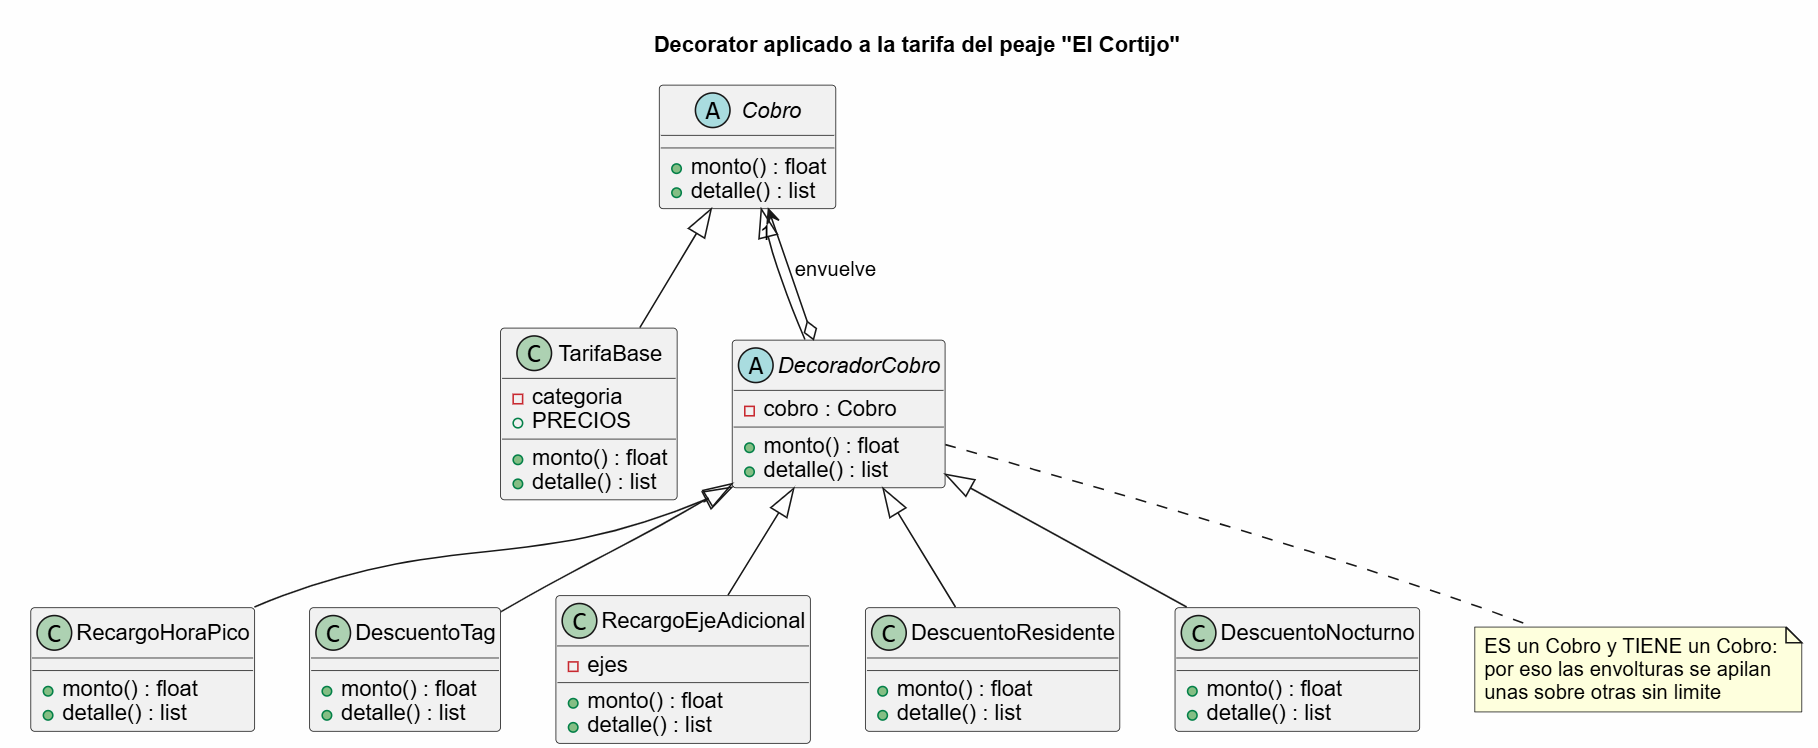



### Código UML

```plantuml
@startuml
title Decorator aplicado a la tarifa del peaje "El Cortijo"

abstract class Cobro {
    + monto() : float
    + detalle() : list
}

class TarifaBase {
    - categoria
    + PRECIOS
    + monto() : float
    + detalle() : list
}

abstract class DecoradorCobro {
    - cobro : Cobro
    + monto() : float
    + detalle() : list
}

class RecargoHoraPico {
    + monto() : float
    + detalle() : list
}

class DescuentoTag {
    + monto() : float
    + detalle() : list
}

class RecargoEjeAdicional {
    - ejes
    + monto() : float
    + detalle() : list
}

class DescuentoResidente {
    + monto() : float
    + detalle() : list
}

class DescuentoNocturno {
    + monto() : float
    + detalle() : list
}

Cobro <|-- TarifaBase
Cobro <|-- DecoradorCobro

DecoradorCobro <|-- RecargoHoraPico
DecoradorCobro <|-- DescuentoTag
DecoradorCobro <|-- RecargoEjeAdicional
DecoradorCobro <|-- DescuentoResidente
DecoradorCobro <|-- DescuentoNocturno

DecoradorCobro o--> "1" Cobro : envuelve

note bottom of DecoradorCobro
  ES un Cobro y TIENE un Cobro:
  por eso las envolturas se apilan
  unas sobre otras sin limite
end note
@enduml
```

## ¿Por qué Decorator y no otro?

Lo que manda acá es que las reglas son acumulativas, no excluyentes. Además, el orden de envoltura es una decisión de negocio aquí decidí que el recargo por eje adicional sí recibe el descuento de residente; si la política fuera otra, bastaría con reordenar el `armar_cobro`

Strategy era el candidato obvio y es con el que más se confunde este caso, pero Strategy cambia un algoritmo por otro: el contexto tiene una estrategia activa a la vez. Yo no quiero elegir una regla, quiero apilar varias. Para lograrlo con Strategy tendría que escribir una `EstrategiaPicoTagResidente` por cada combinación, que es exactamente la explosión de clases que estoy tratando de evitar.

Chain of Responsibility se parece por fuera, también es una cadena de objetos, pero ahí la idea es que uno solo de los eslabones atienda la petición y la cadena se corte. En mi caso todos tienen que aplicarse y los efectos se van componiendo sobre el resultado del anterior.

Proxy igual envuelve, solo que para controlar el acceso al objeto real dejando su comportamiento igual. Yo no controlo el acceso, cambio el resultado. Adapter y Facade ni siquiera aplican, no hay interfaces incompatibles que traducir ni un subsistema enredado que esconder detrás de una puerta.

Lo que no me convence del resultado es que hay que leer la composición de adentro hacia afuera, y con cuatro envolturas eso ya cuesta un poco. A cambio, agregar una regla o cambiar el orden en que se aplican dejó de ser un cambio riesgoso sobre código que ya funcionaba.